[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Fine-Tuning

Every network in this module was trained from random initialization on tens of
thousands of images.  That is not how deep learning is usually practised, and it
is not how you should approach a vision problem of your own.

The reason is arithmetic.  ResNet-18 has 11 million parameters, and ImageNet has
1.2 million images to constrain them.  A realistic problem — classifying defects
on a production line, sorting specimens in a herbarium, telling one cat breed
from another — comes with a few hundred images per class if you are lucky.
Training 11 million parameters on a thousand images will not work.

But it does not have to.  Look back at the first layer AlexNet learned: oriented
edge detectors and colour-opponent blobs.  Nothing about those is specific to
distinguishing 1000 ImageNet categories — they are what the *early* layers of any
vision system need, and the same is true, less strictly, of the middle layers
that build textures and parts out of them.  The task-specific knowledge is
concentrated near the top.

So take a network trained on a large dataset, keep what it learned, and adapt it.
This is **fine-tuning**, and it is probably the single most useful technique in
this module.  You have already seen it once, on the other side of the course: the
LoRA notebook in module 05 adapts a pretrained language model to a new task
rather than training one from scratch.  The logic is identical, and it is worth
seeing it applied to images, where the transferred features are things you can
look at.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import os
import time

import numpy as np
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from matplotlib import pyplot as plt

In [2]:
# if you have a GPU we should enable it
# mps is the pytorch device that supports GPU computations on MacOS

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using {device} device')

Using mps device


## The task: telling cat breeds apart

We use the Oxford-IIIT Pet dataset, which has about 200 photographs each of 37
breeds — 25 dogs and 12 cats — in natural poses, lighting and backgrounds.

> Parkhi, O. M., Vedaldi, A., Zisserman, A., & Jawahar, C. V. (2012). Cats and
> dogs. *IEEE Conference on Computer Vision and Pattern Recognition*.

We restrict to **cats**, and the reason is worth explaining, because it decides
whether this notebook demonstrates anything at all.

ImageNet's 1000 classes were chosen with a deliberate fine-grained challenge
built in: over a hundred of them are dog breeds.  So a network pretrained on
ImageNet has *already been trained to tell beagles from basset hounds* — it has
dedicated output units for them.  Fine-tuning it to classify dog breeds would
produce a spectacular result for an uninteresting reason: the task is not new to
the network.  Cats are barely represented, so the cat breeds are genuinely
unfamiliar and the features have to do real work.

Let's check that claim rather than assert it.  The category list ships with
torchvision's pretrained weights, so we can read it without downloading
anything.

In [3]:
imagenet_classes = ResNet18_Weights.IMAGENET1K_V1.meta['categories']

# not exhaustive -- ImageNet's dog breeds are more numerous than any short
# keyword list will catch, which is itself the point
dog_words = ('terrier', 'spaniel', 'retriever', 'hound', 'setter', 'poodle',
             'sheepdog', 'shepherd', 'collie', 'pointer', 'schnauzer', 'pinscher',
             'mastiff', 'bulldog', 'corgi', 'husky', 'malamute', 'dane', 'pug',
             'chihuahua', 'beagle', 'samoyed', 'pomeranian', 'keeshond', 'basset',
             'papillon', 'pekinese', 'dalmatian', 'newfoundland', 'saint bernard',
             'leonberg', 'pyrenees', 'vizsla', 'weimaraner', 'whippet', 'borzoi',
             'saluki', 'komondor', 'kuvasz', 'briard', 'malinois', 'groenendael',
             'affenpinscher', 'basenji', 'chow', 'brabancon', 'sennenhund',
             'rottweiler', 'elkhound', 'otterhound', 'redbone', 'bluetick',
             'coonhound', 'foxhound', 'boxer', 'griffon', 'schipperke', 'kelpie')
dog_classes = [c for c in imagenet_classes if any(w in c.lower() for w in dog_words)]
cat_classes = [c for c in imagenet_classes
               if c in ('tabby', 'tiger cat', 'Persian cat', 'Siamese cat',
                        'Egyptian cat', 'Angora')]

print(f'ImageNet-1k classes that are dog breeds: at least {len(dog_classes)}')
print(f'ImageNet-1k classes that are domestic cats: {len(cat_classes)}')
print(' ', cat_classes)

ImageNet-1k classes that are dog breeds: at least 98
ImageNet-1k classes that are domestic cats: 6
  ['tabby', 'tiger cat', 'Persian cat', 'Siamese cat', 'Egyptian cat', 'Angora']


Ninety-eight dog classes against six cat classes, and the true dog count is
higher still — no short keyword list catches every breed name in there.  The asymmetry
is not an accident of collection: ILSVRC replaced 90 of its categories with dog
breeds specifically to create a fine-grained challenge within the main task.

Now the data.  The download is about 800 MB from Oxford's servers and happens
once; afterwards it is cached in `data/`.

In [4]:
data_dir = '../data'

# the 12 cat breeds in Oxford-IIIT Pet; the other 25 categories are dogs
CAT_BREEDS = ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair',
              'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue',
              'Siamese', 'Sphynx']

# how many breeds to classify; 10 keeps a run to a few minutes, 12 uses them all
num_breeds = 10

# 'cat' is the interesting case (see above); 'dog' is exercise 1
pet_type = 'cat'

In [5]:
def pet_subset(split, transform, breeds):
    """Oxford-IIIT Pet restricted to the given breeds, with labels renumbered 0..n-1."""
    catalog = datasets.OxfordIIITPet(data_dir, split=split, download=True)
    wanted = sorted(catalog.class_to_idx[breed] for breed in breeds)
    renumber = {old: new for new, old in enumerate(wanted)}
    # _labels holds the breed index of every image, so we can select the ones we
    # want without opening 7000 files just to read their labels
    indices = [i for i, label in enumerate(catalog._labels) if label in renumber]

    dataset = datasets.OxfordIIITPet(data_dir, split=split, transform=transform,
                                     target_transform=renumber.__getitem__)
    return Subset(dataset, indices)

all_breeds = datasets.OxfordIIITPet(data_dir, download=True).classes
if pet_type == 'cat':
    breeds = [b for b in all_breeds if b in CAT_BREEDS][:num_breeds]
else:
    breeds = [b for b in all_breeds if b not in CAT_BREEDS][:num_breeds]

known = {c.lower() for c in imagenet_classes}
print(f'{len(breeds)} {pet_type} breeds:')
for breed in breeds:
    in_imagenet = breed.lower() in known or f'{breed.lower()} cat' in known
    print(f'  {breed:20s}{"  <- already an ImageNet class" if in_imagenet else ""}')

100%|███████████████████████████████████████████████████████████████████████████████| 792M/792M [01:18<00:00, 10.1MB/s]


Extracting data/oxford-iiit-pet/images.tar.gz to data/oxford-iiit-pet


100%|█████████████████████████████████████████████████████████████████████████████| 19.2M/19.2M [00:02<00:00, 8.72MB/s]


Extracting data/oxford-iiit-pet/annotations.tar.gz to data/oxford-iiit-pet
10 cat breeds:
  Abyssinian          
  Bengal              
  Birman              
  Bombay              
  British Shorthair   
  Egyptian Mau        
  Maine Coon          
  Persian               <- already an ImageNet class
  Ragdoll             
  Russian Blue        


Of the ten, only Persian and Siamese are ImageNet categories in their own right
(and "Egyptian Mau" appears there as the generic "Egyptian cat").  The other
seven or eight are new to the network, which is exactly the situation we want to
study.

## Preparing the images

Two things need care here, and both are about matching the pretrained model's
expectations.

**Normalization.**  The pretrained weights were learned on images standardized
with ImageNet's channel means and standard deviations.  Feed it images
standardized any other way and every activation is off-scale — the network is
being shown a kind of data it has never seen.  These six numbers are a property
of the checkpoint, not of our dataset, and they have to be copied exactly.

**Augmentation.**  With roughly a thousand training images and 11 million
parameters, overfitting is the default outcome.  Random resized crops and
horizontal flips manufacture new training examples from old ones, which is what
AlexNet's authors did for the same reason.  Note that augmentation applies to
training only: at validation time we want the same deterministic view of every
image, so we resize and take a centre crop.

In [6]:
# these constants belong to the pretrained weights and must match exactly
normalize = transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize])

train_set = pet_subset('trainval', train_transform, breeds)
val_set = pet_subset('test', val_transform, breeds)

batch_size = 32
train_iter = DataLoader(train_set, batch_size, shuffle=True)
val_iter = DataLoader(val_set, batch_size)

print(f'{len(train_set)} training and {len(val_set)} validation images, '
      f'{len(breeds)} classes')
print(f'{len(train_set) / len(breeds):.0f} training images per class')

989 training and 983 validation images, 10 classes
99 training images per class


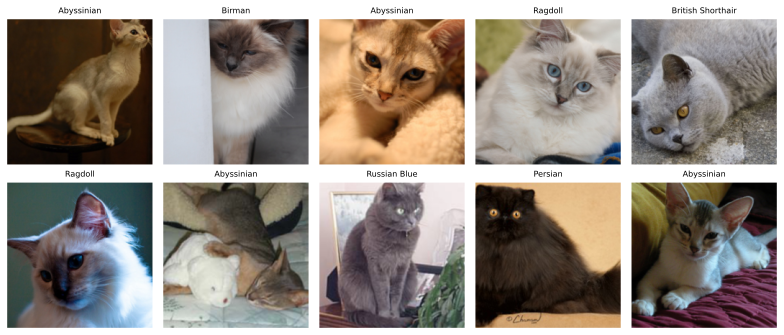

In [7]:
# a look at what we are asking the network to distinguish
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (image * std + mean).clamp(0, 1).permute(1, 2, 0)

batch_X, batch_y = next(iter(DataLoader(val_set, 10, shuffle=True)))
fig, axes = plt.subplots(2, 5, figsize=(11, 4.8))
for ax, image, y in zip(axes.flatten(), batch_X, batch_y):
    ax.imshow(denormalize(image))
    ax.set_title(breeds[y], fontsize=8)
    ax.axis('off')
fig.tight_layout()

## Model surgery

A pretrained ResNet-18 is the network of the previous notebook, trained on
ImageNet.  Its final layer, `fc`, maps 512 pooled features to 1000 class scores —
and 1000 is the one number in the architecture that is about ImageNet rather than
about vision.

So we keep everything else and replace that one layer.

In [8]:
pretrained = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
print('the layer we are replacing:', pretrained.fc)
print(f'it holds {sum(p.numel() for p in pretrained.fc.parameters()):,d} of '
      f'{sum(p.numel() for p in pretrained.parameters()):,d} parameters')

the layer we are replacing: Linear(in_features=512, out_features=1000, bias=True)
it holds 513,000 of 11,689,512 parameters


In [9]:
def make_finetune_model(num_classes, pretrained_weights=True):
    """ResNet-18 with a fresh output layer, optionally starting from ImageNet weights."""
    weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained_weights else None
    model = resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = make_finetune_model(len(breeds))
print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


Everything below `fc` keeps its ImageNet values; `fc` alone is randomly
initialized, because there is nothing to inherit — the classes are new.

### Two learning rates

Now a detail that matters more than it looks.  The body of the network is
already good and needs gentle adjustment.  The head is random and needs to learn
from nothing.  Training both at the same rate is wrong in both directions: fast
enough for the head will wreck the body, and slow enough for the body will leave
the head untrained.

The standard answer is one optimizer with **two parameter groups**: a small
learning rate for the pretrained parameters, and something like ten times that
for the new layer.  This is also a small demonstration that an optimizer's
"learning rate" need not be a single number.

In [10]:
def make_optimizer(model, lr=5e-4, head_multiplier=10):
    """Small steps for the pretrained body, larger ones for the new head."""
    head = list(model.fc.parameters())
    head_ids = {id(p) for p in head}
    body = [p for p in model.parameters() if id(p) not in head_ids]
    return torch.optim.SGD(
        [{'params': body, 'lr': lr},
         {'params': head, 'lr': lr * head_multiplier}],
        momentum=0.9, weight_decay=1e-4)

optimizer = make_optimizer(model)
for i, group in enumerate(optimizer.param_groups):
    print(f'group {i}: {sum(p.numel() for p in group["params"]):>11,d} parameters '
          f'at lr {group["lr"]}')

group 0:  11,176,512 parameters at lr 0.0005
group 1:       5,130 parameters at lr 0.005


## The experiment

Three networks, identical in architecture, differing only in where they start and
what is allowed to move:

1. **fine-tuned** — ImageNet weights, everything trainable;
2. **feature extraction** — ImageNet weights, body frozen, only `fc` trains.
   This is the cheap option: the body becomes a fixed feature extractor and we
   fit a linear model on top of it;
3. **from scratch** — random initialization, everything trainable.  The
   control.

The third is what you would be forced to do without transfer learning, and the
comparison between it and the first is the point of the notebook.

In [11]:
def accuracy(Y_hat, Y):
    """Fraction of correct predictions."""
    return (Y_hat.argmax(dim=1) == Y).float().mean()

def train(model, optimizer, epochs=8, label=''):
    """Train, reporting validation accuracy each epoch."""
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    accuracy_valid = []

    for epoch in range(epochs):
        start = time.time()
        model.train()
        loss_values = []
        for batch_X, batch_y in train_iter:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            loss = loss_fn(model(batch_X), batch_y)
            loss_values.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        accuracy_values = []
        for batch_X, batch_y in val_iter:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            with torch.no_grad():
                accuracy_values.append(accuracy(model(batch_X), batch_y).item())
        accuracy_valid.append(np.mean(accuracy_values))

        print(f'{label:18s} epoch {epoch + 1:2d}  train loss {np.mean(loss_values):.3f}  '
              f'val accuracy {accuracy_valid[-1]:.3f}  ({time.time() - start:.1f} s)')
    return accuracy_valid

In [12]:
torch.manual_seed(0)
finetuned = make_finetune_model(len(breeds))
finetuned_acc = train(finetuned, make_optimizer(finetuned), label='fine-tuned')

fine-tuned         epoch  1  train loss 1.517  val accuracy 0.714  (21.9 s)
fine-tuned         epoch  2  train loss 0.494  val accuracy 0.776  (14.9 s)
fine-tuned         epoch  3  train loss 0.308  val accuracy 0.820  (15.0 s)
fine-tuned         epoch  4  train loss 0.280  val accuracy 0.814  (14.8 s)
fine-tuned         epoch  5  train loss 0.225  val accuracy 0.841  (15.0 s)
fine-tuned         epoch  6  train loss 0.180  val accuracy 0.854  (15.0 s)
fine-tuned         epoch  7  train loss 0.167  val accuracy 0.858  (14.7 s)
fine-tuned         epoch  8  train loss 0.136  val accuracy 0.866  (14.9 s)


In [13]:
torch.manual_seed(0)
frozen = make_finetune_model(len(breeds))
for name, param in frozen.named_parameters():
    param.requires_grad = name.startswith('fc.')
trainable = sum(p.numel() for p in frozen.parameters() if p.requires_grad)
print(f'training {trainable:,d} parameters out of '
      f'{sum(p.numel() for p in frozen.parameters()):,d}\n')

frozen_optimizer = torch.optim.SGD(frozen.fc.parameters(), lr=5e-3,
                                   momentum=0.9, weight_decay=1e-4)
frozen_acc = train(frozen, frozen_optimizer, label='feature extract')

training 5,130 parameters out of 11,181,642

feature extract    epoch  1  train loss 1.572  val accuracy 0.690  (11.5 s)
feature extract    epoch  2  train loss 0.589  val accuracy 0.760  (11.6 s)
feature extract    epoch  3  train loss 0.415  val accuracy 0.794  (11.5 s)
feature extract    epoch  4  train loss 0.396  val accuracy 0.792  (10.9 s)
feature extract    epoch  5  train loss 0.359  val accuracy 0.805  (10.8 s)
feature extract    epoch  6  train loss 0.314  val accuracy 0.815  (10.8 s)
feature extract    epoch  7  train loss 0.305  val accuracy 0.820  (10.8 s)
feature extract    epoch  8  train loss 0.260  val accuracy 0.818  (10.8 s)


In [14]:
torch.manual_seed(0)
scratch = make_finetune_model(len(breeds), pretrained_weights=False)
# a random network needs a much larger step than a pretrained one
scratch_optimizer = torch.optim.SGD(scratch.parameters(), lr=5e-3,
                                    momentum=0.9, weight_decay=1e-4)
scratch_acc = train(scratch, scratch_optimizer, label='from scratch')

from scratch       epoch  1  train loss 2.346  val accuracy 0.162  (14.8 s)
from scratch       epoch  2  train loss 1.992  val accuracy 0.257  (14.8 s)
from scratch       epoch  3  train loss 1.831  val accuracy 0.323  (15.2 s)
from scratch       epoch  4  train loss 1.823  val accuracy 0.341  (14.6 s)
from scratch       epoch  5  train loss 1.771  val accuracy 0.330  (14.8 s)
from scratch       epoch  6  train loss 1.650  val accuracy 0.389  (14.8 s)
from scratch       epoch  7  train loss 1.507  val accuracy 0.408  (14.7 s)
from scratch       epoch  8  train loss 1.567  val accuracy 0.365  (14.9 s)


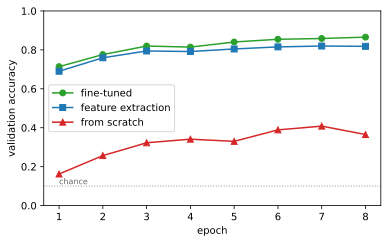

In [15]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
epochs_range = range(1, len(finetuned_acc) + 1)
ax.plot(epochs_range, finetuned_acc, color='C2', marker='o', label='fine-tuned')
ax.plot(epochs_range, frozen_acc, color='C0', marker='s', label='feature extraction')
ax.plot(epochs_range, scratch_acc, color='C3', marker='^', label='from scratch')
ax.axhline(1 / len(breeds), color='0.6', linestyle=':', linewidth=1)
ax.text(1, 1 / len(breeds) + 0.01, 'chance', fontsize=8, color='0.4')
ax.set_xlabel('epoch')
ax.set_ylabel('validation accuracy')
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

The gap is the entire point, and it is not subtle.

The from-scratch network is doing what you would expect of 11 million parameters
and a thousand images: it has nowhere near enough data, and it says so.  The
fine-tuned network reaches an accuracy in a few minutes that the scratch network
would not reach with any amount of patience on this dataset.

The interesting comparison is the other one.  **Feature extraction** — freezing
everything and fitting a linear model on 512 pretrained features — gets most of
the way there while training a few thousand parameters instead of 11 million.
That is worth remembering as a baseline: it is fast, it cannot overfit much, and
on a small dataset it is sometimes the better choice.  Fine-tuning wins when
there is enough data to justify moving the body, and by how much depends on how
far your images are from ImageNet's.

Note what has *not* happened: the fine-tuned model does not overfit badly despite
having 11 million parameters and a thousand images.  Starting from a good
solution is itself a form of regularization — the network never explores the
parts of parameter space where memorizing the training set lives.

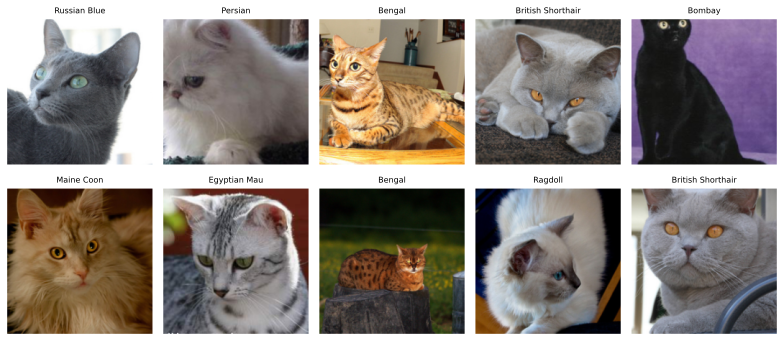

In [16]:
# where does it still go wrong?
model = finetuned.eval()
batch_X, batch_y = next(iter(DataLoader(val_set, 10, shuffle=True)))
with torch.no_grad():
    preds = model(batch_X.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(11, 5.0))
for ax, image, y, pred in zip(axes.flatten(), batch_X, batch_y, preds):
    ax.imshow(denormalize(image))
    correct = (y == pred)
    ax.set_title(breeds[pred] if correct else f'{breeds[pred]}\n(is {breeds[y]})',
                 fontsize=8, color='black' if correct else 'C3')
    ax.axis('off')
fig.tight_layout()

### Saving the trained model

In [17]:
model_path = f'resnet18_{pet_type}_breeds.pt'
torch.save(finetuned.state_dict(), model_path)

reloaded = make_finetune_model(len(breeds), pretrained_weights=False)
reloaded.load_state_dict(torch.load(model_path, map_location='cpu'))
reloaded.eval()
print(f'saved {model_path} ({os.path.getsize(model_path) / 1e6:.1f} MB)')

saved resnet18_cat_breeds.pt (44.8 MB)


/var/folders/5x/wvyx67v13v94f17zl_lh86zw0000gn/T/ipykernel_16007/3615489060.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  reloaded.load_state_dict(torch.load(model_pat

Note `pretrained_weights=False` when reloading.  There is no point downloading
ImageNet weights only to overwrite every one of them with the checkpoint — and it
is a useful reminder that "pretrained" is not a property of the architecture, only
of the numbers you happen to load into it.

## When does this work?

Fine-tuning is close to free, so the useful question is when it stops helping.

**The closer your images are to the pretraining data, the better it transfers.**
Photographs of animals, objects and scenes are what ImageNet is made of, and they
transfer well.  Medical scans, satellite imagery, microscopy and document images
are further away, and the benefit shrinks — though it usually remains positive,
because the earliest layers are generic to *images*, not to photographs.

**The less data you have, the more you should freeze.**  With a few hundred
examples, train only the head; with a few thousand, fine-tune everything at a low
rate; with a few hundred thousand, you may as well train from scratch, though
starting from pretrained weights will still converge faster.

**Watch what your normalization is doing.**  The most common fine-tuning bug is
mismatched preprocessing — feeding images normalized differently from the way the
pretrained model was trained.  It fails quietly, producing a model that works
somewhat, which is harder to notice than one that fails outright.

The same three considerations, almost word for word, govern adapting a pretrained
language model, which is the subject of the LoRA notebook in module 05.  Nothing
about this is specific to images.

## Summary

* **Fine-tuning starts from a network trained on a large dataset** and adapts it,
  rather than training from random initialization.  On a small dataset the
  difference is not incremental — it is the difference between a working model
  and no model.
* **Only the output layer is genuinely task-specific.**  Replace `fc`, keep
  everything below it.
* **Use two learning rates**: a small one for the pretrained body, roughly ten
  times larger for the randomly initialized head.
* **Freezing the body and training only the head** is a cheap and strong
  baseline, especially when data is scarce.
* **Preprocessing must match the pretrained model**, including the exact
  normalization constants.
* **What transfers is the features.**  Because over a hundred ImageNet classes
  are dog breeds, a dog-breed task would have been a poor test — the network
  already knows the answers.  Cat breeds are mostly new to it, so the improvement
  we measured comes from transferred features rather than transferred labels.

## Exercises

1. **The dogs.**  Set `pet_type = 'dog'` at the top and rerun.  Fine-tuning
   should do noticeably better than it did on cats.  Explain why, using the
   ImageNet class counts from the second code cell, and say which of the three
   curves you expect to move most.
2. **How little data is enough?**  Train the fine-tuned and frozen models on 10,
   25 and 100 images per breed.  Plot accuracy against training-set size for
   both.  Where do the two curves cross, and does that match the guidance above?
3. **Turn off augmentation.**  Replace `train_transform` with `val_transform` and
   retrain the fine-tuned model.  How large is the gap between training and
   validation accuracy now, and what does that tell you about how much work the
   augmentation was doing?
4. **Break the normalization.**  Retrain using `transforms.Normalize([0.5] * 3,
   [0.5] * 3)` instead of the ImageNet constants.  How much accuracy do you lose?
   This is the quiet bug described above — see how quiet it is.
5. **Freeze less.**  Instead of freezing everything below `fc`, freeze only the
   stem and `layer1`, leaving `layer2` through `layer4` trainable.  Where is the
   sweet spot between the two extremes we tried?
6. **Look at the features.**  Take the frozen model, extract the 512-dimensional
   pooled features for the whole validation set, and project them to two
   dimensions with PCA, colouring points by breed.  Are the breeds already
   separated before any fine-tuning?
7. **A harder transfer.**  Fine-tune the same pretrained network on Fashion-MNIST
   (you will need to convert to three channels and resize).  Compare against
   ResNet-18 trained from scratch in the previous notebook.  Does ImageNet
   pretraining help on grayscale clothing thumbnails, and why is the answer
   smaller than it was here?
8. Compare this notebook with the LoRA notebook of module 05.  LoRA adapts a
   pretrained model without modifying the original weights at all.  What is the
   equivalent idea here, and why is it more attractive for a 7-billion-parameter
   language model than for an 11-million-parameter ResNet?